In [19]:
#! pip install torch torchvision torchaudio 
#! pip install ultralytics 
#! pip install lightning
#! pip install cnstd
#! pip install cnocr


In [20]:
import requests
from requests.auth import HTTPDigestAuth
import numpy as np
import cv2
from PIL import Image
import json
from cnstd import CnStd
from cnocr import CnOcr
# Parámetros del DVR
ip_dvr = "192.168.0.249"
usuario = "admin"
contrasena = "asd12345"
canal = 5  # Por ejemplo: canal 1 -> 101

# URL del snapshot
url = f"http://{ip_dvr}/ISAPI/Streaming/channels/{canal}01/picture?videoResolutionWidth=1920&videoResolutionHeight=1080"

try:
    response = requests.get(url, auth=HTTPDigestAuth(usuario, contrasena), timeout=5)

    if response.status_code == 200:
        # Convertir bytes a imagen con OpenCV
        img_array = np.frombuffer(response.content, dtype=np.uint8)
        imgen_read = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        if imgen_read is not None:
            print("imagen guardada")
            print(imgen_read.shape)
        else:
            print("❌ No se pudo decodificar la imagen.")
    else:
        print(f"❌ Error al obtener imagen: {response.status_code}")
except Exception as e:
    print(f"❌ Excepción: {e}")


imagen guardada
(1080, 1920, 3)


In [21]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np 
import torch
from torchvision import transforms
## Inicializar el OCR
std = CnStd(context="cpu")
cn_ocr = CnOcr(context="cpu")

# Transformador para convertir imágenes PIL a tensores normalizados
transform = transforms.Compose(
    [
        transforms.ToPILImage(), 
        transforms.Resize((224, 224)),
        transforms.ToTensor(),  # convierte PIL o np.array a [C, H, W] y escala a [0, 1]
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Cargar el modelo completo
model_rot = torch.load("mobilenet_angle_full_model.pt",weights_only=False, map_location=torch.device("cpu"))
model_rot.eval()


# Cargar el model_yoloo completo
model_yolo = YOLO("E:/Users/Documents/Trabajo/MiCasitaCIDetection/best_v180.pt")  # Cambia por "runs/detect/train/weights/best.pt"

import cv2
import numpy as np

def rotar_imagen_cv2(img, angulo):
    """
    Rota una imagen con OpenCV alrededor del centro y ajusta el tamaño del canvas.

    Args:
        img (np.ndarray): Imagen cargada con cv2.
        angulo (float): Ángulo de rotación en grados (positivo: antihorario).

    Returns:
        np.ndarray: Imagen rotada.
    """
    (h, w) = img.shape[:2]
    centro = (w // 2, h // 2)

    # Matriz de rotación
    M = cv2.getRotationMatrix2D(centro, angulo, 1.0)

    # Calcular el nuevo tamaño del canvas para que quepa la imagen completa
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])
    nuevo_ancho = int((h * sin) + (w * cos))
    nuevo_alto = int((h * cos) + (w * sin))

    # Ajustar la matriz de rotación para el nuevo centro
    M[0, 2] += (nuevo_ancho / 2) - centro[0]
    M[1, 2] += (nuevo_alto / 2) - centro[1]

    # Aplicar rotación
    img_rotada = cv2.warpAffine(img, M, (nuevo_ancho, nuevo_alto), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    return img_rotada

[INFO] 2025-06-25 16:58:55,627 [RapidOCR] base.py:24: Using engine_name: onnxruntime
[INFO] 2025-06-25 16:58:55,627 [RapidOCR] main.py:55: Using C:\Users\jeff_\AppData\Roaming\cnstd\1.2\ppocr\ch_PP-OCRv5_det\ch_PP-OCRv5_det_infer.onnx
[INFO] 2025-06-25 16:58:55,720 [RapidOCR] base.py:24: Using engine_name: onnxruntime
[INFO] 2025-06-25 16:58:55,721 [RapidOCR] main.py:55: Using C:\Users\jeff_\AppData\Roaming\cnstd\1.2\ppocr\ch_PP-OCRv4_det\ch_PP-OCRv4_det_infer.onnx



0: 384x640 None57.9ms
Speed: 2.3ms preprocess, 57.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
[[     1008.6      448.47      97.615      319.68      1.4748]
 [     1365.1      305.77      74.867      367.78      1.4887]]
84.50211


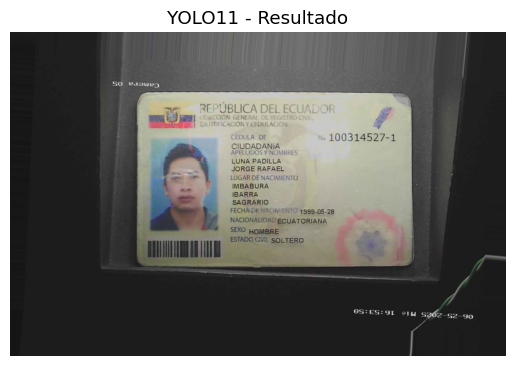

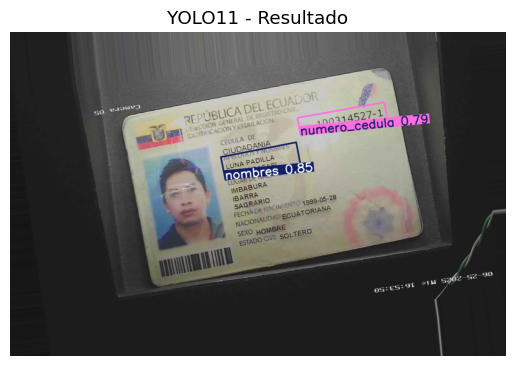

In [22]:
#SOURCE_PATH = "E:/Users/Documents/Trabajo/Cedulas/imagenes_cedula_peq/Cedula_Guayaquil/ImagenCedula_27icvzE.jpg"  # Ruta de la imagen
#image = cv2.imread(SOURCE_PATH)
#image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img = transform(imgen_read).unsqueeze(0)   # Añadir batch dimension

with torch.no_grad():
    pred = model_rot(img)
    pred_angle = pred.item() * 180 / np.pi  # Convertir a grados

image=rotar_imagen_cv2(imgen_read,-pred_angle)

# Cargar imagen con PIL
# Realizar inferencia
results = model_yolo(image,conf=0.7)
# Mostrar resultados usando PIL
for result in results:
    # result.plot() devuelve una imagen NumPy (BGR), la convertimos a RGB para PIL
    img_array = result.plot()[:, :, ::-1]
    data=result.obb.xywhr.cpu().numpy()
    points=result.obb.xyxyxyxy.cpu().numpy()
    print(data)
    print(np.degrees(data[0][-1]))
    #np.degrees(data[1][-1])-90
    if np.degrees(data[0][-1])>45:
        angle_corr=np.degrees(data[0][-1])-90
    else:
        angle_corr=np.degrees(data[0][-1])
    result_image = rotar_imagen_cv2(img_array,-angle_corr)
    img_rot=rotar_imagen_cv2(image,angle_corr)
    img_rot = cv2.cvtColor(img_rot, cv2.COLOR_BGR2RGB)
    %matplotlib inline

    # Mostrar usando matplotlib
    plt.imshow(img_rot)
    plt.axis('off')
    plt.title("YOLO11 - Resultado")
    plt.show()
    image_pros = rotar_imagen_cv2(image,-angle_corr)

    # Mostrar usando matplotlib
    plt.imshow(result_image)
    plt.axis('off')
    plt.title("YOLO11 - Resultado")
    plt.show()


In [23]:
import numpy as np
import math

def angulo_desde_4_puntos(puntos):
    """
    Calcula el ángulo de rotación (en grados) de un rectángulo definido por 4 puntos.

    Args:
        puntos (list): Lista de 4 puntos [[x1,y1], [x2,y2], [x3,y3], [x4,y4]].

    Returns:
        float: Ángulo de rotación en grados. Sentido antihorario desde el eje X.
    """
    # Convertir a numpy
    pts = np.array(puntos, dtype="float32")

    # Ordenar los puntos: top-left, top-right, bottom-right, bottom-left
    def ordenar_puntos(pts):
        rect = np.zeros((4, 2), dtype="float32")
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]     # top-left
        rect[2] = pts[np.argmax(s)]     # bottom-right

        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]  # top-right
        rect[3] = pts[np.argmax(diff)]  # bottom-left
        return rect

    rect = ordenar_puntos(pts)
    (tl, tr, _, _) = rect

    # Vector horizontal (de top-left a top-right)
    dx = tr[0] - tl[0]
    dy = tr[1] - tl[1]

    # Calcular ángulo en radianes y convertir a grados
    angle_rad = math.atan2(dy, dx)
    angle_deg = math.degrees(angle_rad)

    return angle_deg
angulo = angulo_desde_4_puntos(points[0])
print(f"Ángulo: {angulo:.2f}°")


Ángulo: -5.50°


In [24]:
import cv2
import numpy as np

def recorte_desde_4_puntos(imagen, puntos, expand_w=0, expand_h=0, scale=1.0):
    """
    Recorta una región definida por 4 puntos, la endereza,
    permite expansión manual en ancho y alto, y aplica escala final.

    Args:
        imagen (np.ndarray): Imagen original.
        puntos (list): Lista de 4 puntos [[x1,y1], [x2,y2], [x3,y3], [x4,y4]].
        expand_w (float): Expansión horizontal (en píxeles o % si < 1).
        expand_h (float): Expansión vertical (en píxeles o % si < 1).
        scale (float): Escala de la imagen de salida.

    Returns:
        np.ndarray: Imagen recortada, alineada y escalada.
    """
    # Convertir a float32
    pts = np.array(puntos, dtype="float32")

    # Ordenar: top-left, top-right, bottom-right, bottom-left
    def ordenar_puntos(pts):
        rect = np.zeros((4, 2), dtype="float32")
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]     # top-left
        rect[2] = pts[np.argmax(s)]     # bottom-right

        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]  # top-right
        rect[3] = pts[np.argmax(diff)]  # bottom-left
        return rect

    rect = ordenar_puntos(pts)

    # Calcular dimensiones originales
    ancho_sup = np.linalg.norm(rect[1] - rect[0])
    ancho_inf = np.linalg.norm(rect[2] - rect[3])
    alto_izq = np.linalg.norm(rect[3] - rect[0])
    alto_der = np.linalg.norm(rect[2] - rect[1])

    max_ancho = max(ancho_sup, ancho_inf)
    max_alto = max(alto_izq, alto_der)

    # Si expansión es porcentaje, convertir a píxeles
    if expand_w < 1:
        expand_w *= max_ancho
    if expand_h < 1:
        expand_h *= max_alto

    # Expandir alrededor del centro
    centro = np.mean(rect, axis=0)
    rect_expandido = []
    for punto in rect:
        dx, dy = punto - centro
        nuevo_punto = centro + [
            dx * (1 + expand_w / max_ancho),
            dy * (1 + expand_h / max_alto)
        ]
        rect_expandido.append(nuevo_punto)
    rect_expandido = np.array(rect_expandido, dtype="float32")

    # Limitar a la imagen
    h, w = imagen.shape[:2]
    rect_expandido[:, 0] = np.clip(rect_expandido[:, 0], 0, w - 1)
    rect_expandido[:, 1] = np.clip(rect_expandido[:, 1], 0, h - 1)

    # Redefinir ancho y alto después de expansión
    (tl, tr, br, bl) = rect_expandido
    ancho_sup = np.linalg.norm(tr - tl)
    ancho_inf = np.linalg.norm(br - bl)
    max_ancho = int(max(ancho_sup, ancho_inf) * scale)

    alto_izq = np.linalg.norm(bl - tl)
    alto_der = np.linalg.norm(br - tr)
    max_alto = int(max(alto_izq, alto_der) * scale)

    # Puntos destino (imagen recta)
    dst = np.array([
        [0, 0],
        [max_ancho - 1, 0],
        [max_ancho - 1, max_alto - 1],
        [0, max_alto - 1]
    ], dtype="float32")

    # Transformación de perspectiva
    M = cv2.getPerspectiveTransform(rect_expandido, dst)
    warped = cv2.warpPerspective(imagen, M, (max_ancho, max_alto))

    # Convertir a RGB si era BGR (opcional)
    #warped = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

    return warped


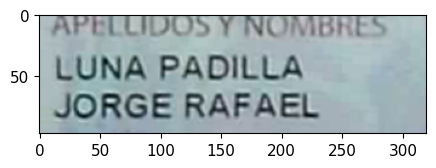

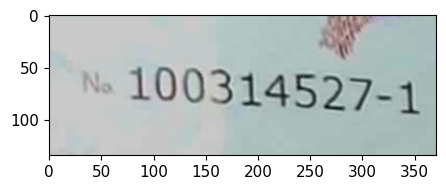

In [25]:
i=0
recortado_rotado = []
recortado_rotado.append(recorte_desde_4_puntos(image, points[0],scale=1,expand_h=1,expand_w=1))
img_result=Image.fromarray(recortado_rotado[0])
plt.figure(figsize=(5,5))
plt.imshow(img_result,cmap="gray") 
recortado_rotado.append(recorte_desde_4_puntos(image, points[1],scale=1,expand_h=0.8,expand_w=1))
img_result=Image.fromarray(recortado_rotado[1])
plt.figure(figsize=(5,5))
plt.imshow(img_result,cmap="gray") 
i+=1

In [26]:
for rec in recortado_rotado:
    box_infos = std.detect(rec)
    for box_info in box_infos['detected_texts']:
        cropped_img = box_info['cropped_img']
        ocr_res = cn_ocr.ocr_for_single_line(cropped_img)
        print('ocr result: %s' % str(ocr_res))

ocr result: {'text': 'LUNA', 'score': 0.770124614238739}
ocr result: {'text': 'PADILLA', 'score': 0.9033925533294678}
ocr result: {'text': 'JORGE RAFAEL', 'score': 0.8005578517913818}
ocr result: {'text': '100314527-1', 'score': 0.5216153264045715}


In [27]:
#SOURCE_PATH = "E:/Users/Documents/Trabajo/Cedulas/imagenes_cedula_peq/Licencias/ImagenCedula_241anjH.jpg"  # Ruta de la imagen
#image_pros = cv2.imread(SOURCE_PATH)
#image_pros = cv2.cvtColor(image_pros, cv2.COLOR_BGR2RGB)
box_infos = std.detect(image_pros)
for box_info in box_infos['detected_texts']:
    cropped_img = box_info['cropped_img']
    ocr_res = cn_ocr.ocr_for_single_line(cropped_img)
    print('ocr result: %s' % str(ocr_res))

ocr result: {'text': 'paaweo', 'score': 0.404937744140625}
ocr result: {'text': 'so', 'score': 0.584154486656189}
ocr result: {'text': 'REPUBLICA DEL ECUADOR', 'score': 0.5699441432952881}
ocr result: {'text': 'REGISTRO CVIL', 'score': 0.5150957703590393}
ocr result: {'text': '100314527-1', 'score': 0.9422353506088257}
ocr result: {'text': '百m', 'score': 0.19550135731697083}
ocr result: {'text': 'No', 'score': 0.24724464118480682}
ocr result: {'text': 'DBECION GENERAL DE', 'score': 0.5009936690330505}
ocr result: {'text': 'IDENTIFICACION Y CFDULACION', 'score': 0.6881573796272278}
ocr result: {'text': 'CEDULA DE', 'score': 0.6798977851867676}
ocr result: {'text': 'CIUDADANiA', 'score': 0.9418141841888428}
ocr result: {'text': 'APELLIDOS Y NOMBRES', 'score': 0.3765610456466675}
ocr result: {'text': 'LUNA PADILLA', 'score': 0.5085139274597168}
ocr result: {'text': 'JORGE RAFAEL', 'score': 0.8209593892097473}
ocr result: {'text': 'LUGAR DE NACIMIENTO', 'score': 0.7153462767601013}
ocr res